In [1]:
pip install compressai

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from skimage import data
from torchvision import transforms
from PIL import Image

from compressai.zoo import bmshj2018_hyperprior
import os


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


🚀 1. 모델을 불러오는 중입니다...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-2-93677231.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-2-93677231.pth.tar


100%|██████████| 20.2M/20.2M [00:00<00:00, 25.6MB/s]


🖼️ 2. 이미지를 불러오고 텐서로 변환합니다...
🪄 3. AI 모델이 압축(인코딩)과 복원(디코딩)을 수행합니다!
📊 4. 결과를 화면에 띄웁니다!


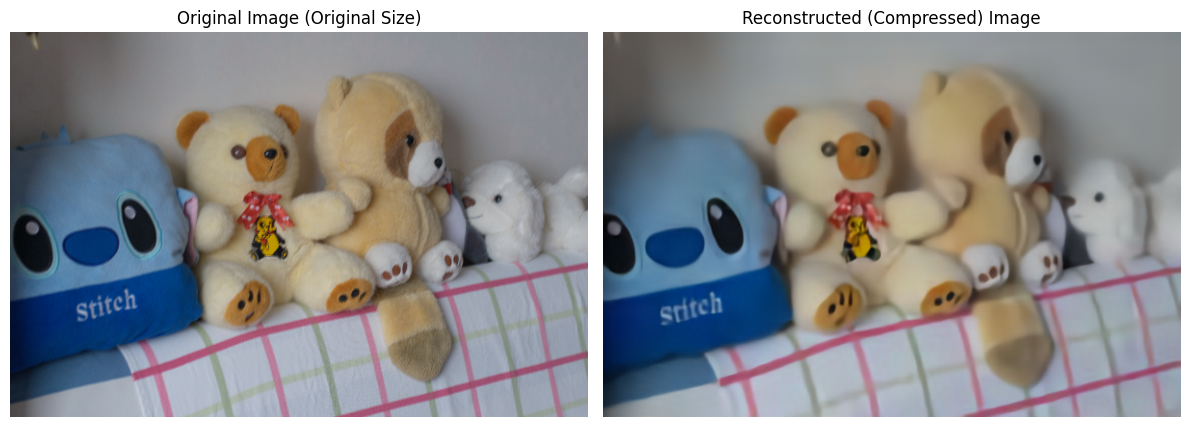

In [4]:
print("🚀 1. 모델을 불러오는 중입니다...")
# quality는 1~8까지 있으며, 숫자가 낮을수록 용량이 작아지고 화질이 깨집니다.
model = bmshj2018_hyperprior(quality=2, pretrained=True).eval()

print("🖼️ 2. 이미지를 불러오고 텐서로 변환합니다...")
# 이미지 경로를 본인 사진 이름으로 맞춰주세요!
img = Image.open('/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/our485/high/10.png').convert('RGB')

# 이미지 크기를 64의 배수로 계산하기
w, h = img.size
new_w = (w // 64) * 64  # 64로 나눈 몫에 다시 64를 곱해서 배수로 맞춤
new_h = (h // 64) * 64

transform = transforms.Compose([
    transforms.CenterCrop((new_h, new_w)),
    transforms.ToTensor()
])

x = transform(img).unsqueeze(0)  # 이미지를 PyTorch 텐서 [1, 3, H, W] 모양으로 변환

print("🪄 3. AI 모델이 압축(인코딩)과 복원(디코딩)을 수행합니다!")
with torch.no_grad():  # 테스트 단계이므로 학습 방지
    # 모델 통과! out_net 딕셔너리에 결과가 담깁니다.
    out_net = model(x)

    # 'x_hat'이 바로 압축되었다가 다시 복원된 이미지입니다.
    x_hat = out_net['x_hat']

print("📊 4. 결과를 화면에 띄웁니다!")
# 텐서를 다시 눈으로 볼 수 있는 이미지로 변환
x_hat = x_hat.squeeze(0).clamp(0, 1) # 범위를 0~1 사이로 안전하게 맞춤
img_hat = transforms.ToPILImage()(x_hat)

# 원본 vs 복원 이미지 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title("Original Image (Original Size)")
axes[0].axis('off')

axes[1].imshow(img_hat)
axes[1].set_title("Reconstructed (Compressed) Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

🚀 1. 모델 불러오기 및 엔트로피 코더 업데이트...
🖼️ 2. 이미지 불러오기 및 64의 배수로 크롭(자르기)...
✅ 안전하게 잘린 텐서 크기: torch.Size([1, 3, 384, 576])
🗜️ 3. 모델을 통해 진짜 바이너리 데이터로 압축(Compress)합니다!

📂 원본 사진 용량 (참고용): 305.48 KB
✨ AI 모델 압축 용량: 1.15 KB
📊 BPP (Bits Per Pixel): 0.0425 bits/pixel

🪄 4. 압축된 데이터를 다시 이미지로 복원(Decompress)합니다!


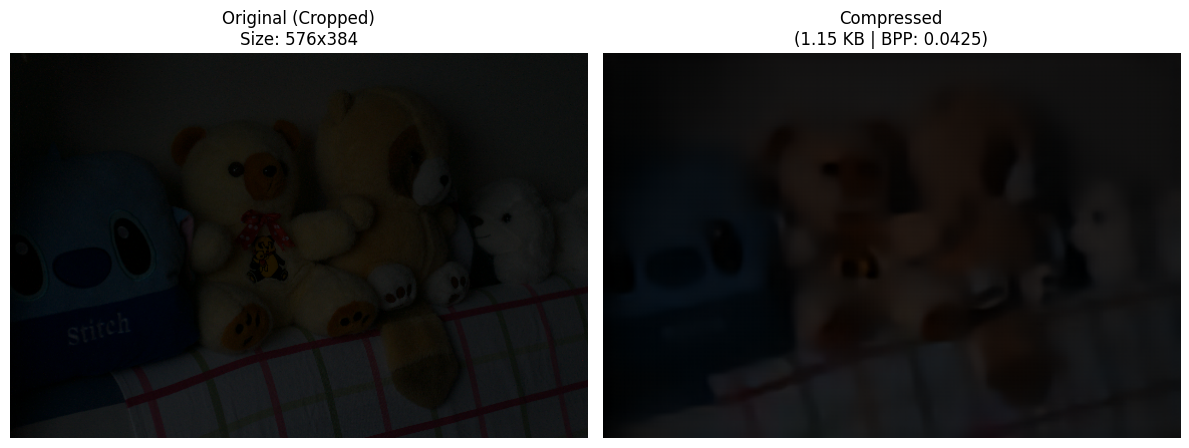

In [6]:
print("🚀 1. 모델 불러오기 및 엔트로피 코더 업데이트...")
model = bmshj2018_hyperprior(quality=2, pretrained=True).eval()

# ★핵심★ 실제 바이너리로 압축하기 전 확률 분포(CDF) 세팅
model.update(force=True)

print("🖼️ 2. 이미지 불러오기 및 64의 배수로 크롭(자르기)...")
# 코랩 환경에 맞게 경로를 설정하세요. (드라이브 마운트 시 '/content/drive/MyDrive/test.jpg' 등)
img_path = '/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/our485/low/10.png'
img = Image.open(img_path).convert('RGB')

# 이미지 가로/세로를 64의 배수로 맞춤 (에러 방지)
w, h = img.size
new_w = (w // 64) * 64
new_h = (h // 64) * 64

transform = transforms.Compose([
    transforms.CenterCrop((new_h, new_w)),
    transforms.ToTensor()
])
x = transform(img).unsqueeze(0)
print(f"✅ 안전하게 잘린 텐서 크기: {x.shape}")

print("🗜️ 3. 모델을 통해 진짜 바이너리 데이터로 압축(Compress)합니다!")
with torch.no_grad():
    compressed_data = model.compress(x)

# 압축된 데이터의 길이(용량) 계산
bitstream_y = compressed_data['strings'][0][0]
bitstream_z = compressed_data['strings'][1][0]

total_bytes = len(bitstream_y) + len(bitstream_z)
total_kb = total_bytes / 1024

print("\n=====================================")
# 디스크의 원본 용량은 크롭되기 전 원본 기준이므로 참고용으로만 보세요!
print(f"📂 원본 사진 용량 (참고용): {os.path.getsize(img_path) / 1024:.2f} KB")
print(f"✨ AI 모델 압축 용량: {total_kb:.2f} KB")

# ★ BPP (Bits Per Pixel) 계산 ★
num_pixels = new_w * new_h  # 크롭된 이미지 기준 픽셀 수
bpp = (total_bytes * 8) / num_pixels
print(f"📊 BPP (Bits Per Pixel): {bpp:.4f} bits/pixel")
print("=====================================\n")

print("🪄 4. 압축된 데이터를 다시 이미지로 복원(Decompress)합니다!")
with torch.no_grad():
    decompressed_data = model.decompress(compressed_data['strings'], compressed_data['shape'])
    x_hat = decompressed_data['x_hat']

# 시각화
x_hat = x_hat.squeeze(0).clamp(0, 1)
img_hat = transforms.ToPILImage()(x_hat)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 시각화할 때도 비교를 위해 크롭된 원본 이미지를 보여줍니다.
axes[0].imshow(transform(img).squeeze(0).permute(1, 2, 0))
axes[0].set_title(f"Original (Cropped)\nSize: {new_w}x{new_h}")
axes[0].axis('off')

axes[1].imshow(img_hat)
axes[1].set_title(f"Compressed\n({total_kb:.2f} KB | BPP: {bpp:.4f})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

🚀 1. 모델 불러오기 및 엔트로피 코더 업데이트...
🖼️ 2. 이미지 불러오기 및 64의 배수로 크롭(자르기)...
✅ 안전하게 잘린 텐서 크기: torch.Size([1, 3, 320, 512])
🗜️ 3. 모델을 통해 진짜 바이너리 데이터로 압축(Compress)합니다!

📂 원본 사진 용량 (참고용): 86.11 KB
✨ AI 모델 압축 용량: 9.02 KB
📊 BPP (Bits Per Pixel): 0.4512 bits/pixel

🪄 4. 압축된 데이터를 다시 이미지로 복원(Decompress)합니다!


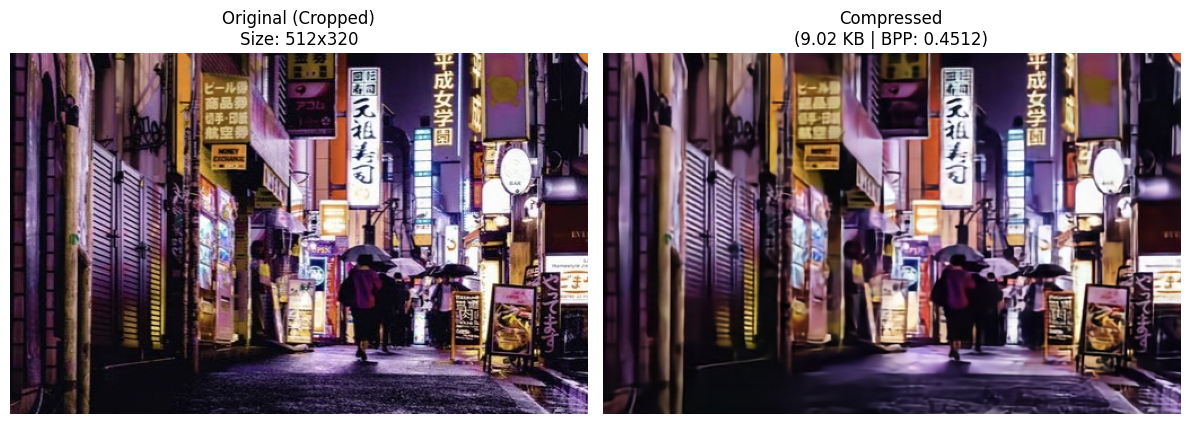

In [8]:
print("🚀 1. 모델 불러오기 및 엔트로피 코더 업데이트...")
model = bmshj2018_hyperprior(quality=2, pretrained=True).eval()

# ★핵심★ 실제 바이너리로 압축하기 전 확률 분포(CDF) 세팅
model.update(force=True)

print("🖼️ 2. 이미지 불러오기 및 64의 배수로 크롭(자르기)...")
# 코랩 환경에 맞게 경로를 설정하세요. (드라이브 마운트 시 '/content/drive/MyDrive/test.jpg' 등)
img_path = '/content/야간 길거리.jpg'
img = Image.open(img_path).convert('RGB')

# 이미지 가로/세로를 64의 배수로 맞춤 (에러 방지)
w, h = img.size
new_w = (w // 64) * 64
new_h = (h // 64) * 64

transform = transforms.Compose([
    transforms.CenterCrop((new_h, new_w)),
    transforms.ToTensor()
])
x = transform(img).unsqueeze(0)
print(f"✅ 안전하게 잘린 텐서 크기: {x.shape}")

print("🗜️ 3. 모델을 통해 진짜 바이너리 데이터로 압축(Compress)합니다!")
with torch.no_grad():
    compressed_data = model.compress(x)

# 압축된 데이터의 길이(용량) 계산
bitstream_y = compressed_data['strings'][0][0]
bitstream_z = compressed_data['strings'][1][0]

total_bytes = len(bitstream_y) + len(bitstream_z)
total_kb = total_bytes / 1024

print("\n=====================================")
# 디스크의 원본 용량은 크롭되기 전 원본 기준이므로 참고용으로만 보세요!
print(f"📂 원본 사진 용량 (참고용): {os.path.getsize(img_path) / 1024:.2f} KB")
print(f"✨ AI 모델 압축 용량: {total_kb:.2f} KB")

# ★ BPP (Bits Per Pixel) 계산 ★
num_pixels = new_w * new_h  # 크롭된 이미지 기준 픽셀 수
bpp = (total_bytes * 8) / num_pixels
print(f"📊 BPP (Bits Per Pixel): {bpp:.4f} bits/pixel")
print("=====================================\n")

print("🪄 4. 압축된 데이터를 다시 이미지로 복원(Decompress)합니다!")
with torch.no_grad():
    decompressed_data = model.decompress(compressed_data['strings'], compressed_data['shape'])
    x_hat = decompressed_data['x_hat']

# 시각화
x_hat = x_hat.squeeze(0).clamp(0, 1)
img_hat = transforms.ToPILImage()(x_hat)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 시각화할 때도 비교를 위해 크롭된 원본 이미지를 보여줍니다.
axes[0].imshow(transform(img).squeeze(0).permute(1, 2, 0))
axes[0].set_title(f"Original (Cropped)\nSize: {new_w}x{new_h}")
axes[0].axis('off')

axes[1].imshow(img_hat)
axes[1].set_title(f"Compressed\n({total_kb:.2f} KB | BPP: {bpp:.4f})")
axes[1].axis('off')

plt.tight_layout()
plt.show()